I figured it gets stuck because we get the wrong coeffs; what if we do weighted least squares with the weights equal to 1 / mse_i?

In [1]:
# %% Imports
from jax import random, numpy as jnp

from modax.data.kdv import DoubleSoliton
from modax.models import DeepmodBayes
from flax import optim
from modax.losses.bayesian import loss_fn_mse_precalc
from modax.training import train_probabilistic_mse, train_probabilistic_simple
from conditional_gaussian import *
from modax.losses.utils import mse

from modax.linear_model import ridge

import matplotlib.pyplot as plt

%load_ext autoreload
%autoreload 2

In [2]:
# %% Making data
key = random.PRNGKey(42)

x = jnp.linspace(-10, 10, 100)
t = jnp.linspace(0.1, 1.0, 10)
t_grid, x_grid = jnp.meshgrid(t, x, indexing="ij")

u = DoubleSoliton(x_grid, t_grid, c=[5.0, 2.0], x0=[0.0, -5.0])

X = jnp.concatenate([t_grid.reshape(-1, 1), x_grid.reshape(-1, 1)], axis=1)
y = u.reshape(-1, 1)
y += 0.1 * jnp.std(y) * random.normal(key, y.shape)

In [5]:
model = DeepmodBayes([30, 30, 30, 1])
variables = model.init(key, X)

optimizer = optim.Adam(learning_rate=2e-3, beta1=0.99, beta2=0.99)
state, params = variables.pop("params")
optimizer = optimizer.create(params)

In [6]:
# only train mse, stop at minimum mse testset
optimizer, state = train_probabilistic_mse(
    model,
    optimizer,
    state,
    loss_fn_mse_precalc,
    X,
    y,
    max_epochs=1e4,
    split=0.8,
    rand_seed=42,
)

Loss step 0.0: 214.76449584960938
Loss step 1000.0: -301.3000183105469
Loss step 2000.0: -347.2919616699219
Loss step 3000.0: -408.96722412109375
Loss step 4000.0: -445.55224609375
Loss step 5000.0: -482.67669677734375


In [7]:
variables = {"params": optimizer.target, **state}
prediction, dt, theta, coeffs, _ = model.apply(variables, X, mutable=list(state.keys()))[0]

Least squares coeffs results in:

In [27]:
coeffs

DeviceArray([[ 0.03994138],
             [-1.1709709 ],
             [-0.28326285],
             [-0.5694959 ],
             [-0.20659962],
             [-5.5564566 ],
             [ 0.6389691 ],
             [ 0.46549642],
             [ 0.22685657],
             [ 1.7799481 ],
             [-0.18750787],
             [-0.09181926]], dtype=float32)

Now let's do weighted least squares. Let's normalize the weight matrix by the variance:

In [ ]:
w =  jnp.diag((jnp.var(y - prediction) / (prediction - y)**2).squeeze())

In [ ]:
X_prime = jnp.sqrt(w) @ theta
y_prime = jnp.sqrt(w) @ dt

In [ ]:
jnp.linalg.lstsq(X_prime, y_prime)

In [ ]:
jnp.linalg.lstsq(theta, dt)

Which is remarkably good. In the normal case, W is an identity matrix, so what if we normalize with that?

In [ ]:
w =  1 /  (prediction - y)**2
w = jnp.diag((w / jnp.sum(w) * prediction.shape[0]).squeeze())

In [ ]:
X_prime = jnp.sqrt(w) @ theta
y_prime = jnp.sqrt(w) @ dt

In [ ]:
jnp.linalg.lstsq(X_prime, y_prime)

In [ ]:
coeffs = jnp.linalg.lstsq(X_prime, y_prime)[0]

jnp.mean((y_prime - X_prime @ coeffs)**2)

Let's check if our algo works by setting W = eye.

In [ ]:
w = jnp.eye(prediction.shape[0])

In [ ]:
X_prime = jnp.sqrt(w) @ theta
y_prime = jnp.sqrt(w) @ dt

In [ ]:
jnp.linalg.lstsq(X_prime, y_prime)

In [ ]:
w = jnp.eye(prediction.shape[0])
print(w.sum())

In [ ]:
w =  1 /  (prediction - y)**2
w = jnp.diag((w / jnp.sum(w) * prediction.shape[0]).squeeze())

print(w.sum())

now what if we calculate the coeffs on the correct set, then use those coeffs for the wrong set?

In [ ]:
w =  jnp.minimum(jnp.var((prediction - y)) /  (prediction - y)**2, 1.0).squeeze()
X_prime = jnp.sqrt(jnp.diag(w)) @ theta
y_prime = jnp.sqrt(jnp.diag(w)) @ dt
jnp.linalg.lstsq(X_prime, y_prime)

In [ ]:
coeffs = jnp.linalg.lstsq(X_prime, y_prime)[0]
jnp.mean((dt - theta @ coeffs)**2)

In [ ]:
coeffs

In [ ]:
ridge(X_prime, y_prime, 1e-5)

that could work....

Now lets write the loss function, first for a normal pinn:

In [ ]:
def loss_fn_pinn_weighted(params, state, model, x, y):
    variables = {"params": params, **state}
    (prediction, dt, theta, coeffs, z), updated_state = model.apply(
        variables, x, mutable=list(state.keys())
    )
    
    w =  jnp.minimum(jnp.var((prediction - y)) /((prediction - y)**2 + 1e-6), 1.0)
    w = jnp.diag(w.squeeze())
    X_prime = jnp.sqrt(w) @ theta
    y_prime = jnp.sqrt(w) @ dt
    weighted_coeffs = jnp.linalg.lstsq(X_prime, y_prime)[0]

    MSE = mse(prediction, y)
    Reg = mse(dt, theta @ weighted_coeffs)
    loss = MSE + Reg
    metrics = {"loss": loss, "mse": MSE, "reg": Reg, "coeff": coeffs, "weighted_coeffs": weighted_coeffs}

    return loss, (updated_state, metrics, (prediction, dt, theta, coeffs))

In [ ]:
model = DeepmodBayes([30, 30, 30, 1])
variables = model.init(key, X)

optimizer = optim.Adam(learning_rate=1e-3, beta1=0.99, beta2=0.99)
state, params = variables.pop("params")
optimizer = optimizer.create(params)

In [ ]:
# only train mse, stop at minimum mse testset
optimizer, state = train_probabilistic_mse(
    model,
    optimizer,
    state,
    loss_fn_pinn_weighted,
    X,
    y,
    max_epochs=1e4,
    split=0.8,
    rand_seed=42,
)

In [ ]:
variables = {"params": optimizer.target, **state}
prediction, dt, theta, coeffs, _ = model.apply(variables, X, mutable=list(state.keys()))[0]

In [ ]:
frame = 3
plt.plot(x, u[frame, :])
plt.plot(x, prediction.reshape(x_grid.shape)[frame, :], 'o')
plt.plot(x, y.reshape(x_grid.shape)[frame, :], 'x')

In [ ]:
def loss_fn_pinn(params, state, model, x, y):
    variables = {"params": params, **state}
    (prediction, dt, theta, coeffs, z), updated_state = model.apply(
        variables, x, mutable=list(state.keys())
    )
    

    MSE = mse(prediction, y)
    Reg = mse(dt, theta @ coeffs)
    loss = MSE + Reg
    metrics = {"loss": loss, "mse": MSE, "reg": Reg, "coeff": coeffs}

    return loss, (updated_state, metrics, (prediction, dt, theta, coeffs))

In [ ]:
model = DeepmodBayes([30, 30, 30, 1])
variables = model.init(key, X)

optimizer = optim.Adam(learning_rate=1e-3, beta1=0.99, beta2=0.99)
state, params = variables.pop("params")
optimizer = optimizer.create(params)

In [ ]:
# only train mse, stop at minimum mse testset
optimizer, state = train_probabilistic_mse(
    model,
    optimizer,
    state,
    loss_fn_pinn,
    X,
    y,
    max_epochs=1e4,
    split=0.8,
    rand_seed=42,
)

Okay so it's not worse... Now let's check it out with bayes:

In [34]:
def loss_fn_weighted_all(params, state, model, x, y):
    """ first argument should always be params!
    """
    variables = {"params": params, **state}
    (prediction, dt, theta, coeffs, z), updated_state = model.apply(
        variables, x, mutable=list(state.keys())
    )
    
    w =  jnp.var((prediction - y)) /((prediction - y)**2 + 1e-6)
    w = jnp.diag(w.squeeze())
    X_prime = jnp.sqrt(w) @ theta
    y_prime = jnp.sqrt(w) @ dt
    weighted_coeffs = ridge(X_prime, y_prime, 1e-6)

    tau_ml = 1 / jnp.mean((prediction - y) ** 2)
    p_mse, MSE = normal_LL(prediction, y, tau_ml)

    nu_ml = 1 / jnp.mean((dt - theta @ weighted_coeffs) ** 2)
    p_reg, reg = normal_LL(dt, theta @ weighted_coeffs, nu_ml)

    loss = -(p_mse + p_reg)

    metrics = {
        "loss": loss,
        "p_mse": p_mse,
        "mse": MSE,
        "p_reg": p_reg,
        "reg": reg,
        "coeff": weighted_coeffs,
        "tau": tau_ml,
        "nu": nu_ml,
        "frac": jnp.mean(jnp.diag(w))
    }
    return loss, (updated_state, metrics, (prediction, dt, theta, coeffs))

In [48]:
def weighted_normal_LL(x, mu, tau, w):
    # tau = 1 / sigma**2, for numerical reasons.
    n_samples = x.shape[0]

    mse = jnp.sum(w * (x - mu) ** 2)
    # 2 before tau to compensate for 1/2
    p = - 1 / 2 * (mse - jnp.sum(jnp.log(w)) + jnp.sum(w * jnp.log(2 * jnp.pi)))
    return p, mse

def loss_fn_weighted_reg(params, state, model, x, y):
    """ first argument should always be params!
    """
    variables = {"params": params, **state}
    (prediction, dt, theta, coeffs, z), updated_state = model.apply(
        variables, x, mutable=list(state.keys())
    )
    
    w =  jnp.var((prediction - y)) /((prediction - y)**2 + 1e-6)
    w = 1e3 * w / jnp.sum(w) # normalizing w

    w = jnp.diag(w.squeeze())
    X_prime = jnp.sqrt(w) @ theta
    y_prime = jnp.sqrt(w) @ dt
    weighted_coeffs = ridge(X_prime, y_prime, 1e-6)

    tau_ml = 1 / jnp.mean((prediction - y) ** 2)
    p_mse, MSE = normal_LL(prediction, y, tau_ml)

    nu_ml = jnp.sum(w) / jnp.sum((y_prime - X_prime @ weighted_coeffs) ** 2)
    p_reg, reg = weighted_normal_LL(y_prime, X_prime @ weighted_coeffs, nu_ml, w)

    loss = -(p_mse + p_reg)

    metrics = {
        "loss": loss,
        "p_mse": p_mse,
        "mse": MSE,
        "p_reg": p_reg,
        "reg": reg,
        "coeff": weighted_coeffs,
        "tau": tau_ml,
        "nu": nu_ml,
        "frac": jnp.mean(jnp.diag(w))
    }
    return loss, (updated_state, metrics, (prediction, dt, theta, coeffs))

In [49]:
model = DeepmodBayes([30, 30, 30, 1])
variables = model.init(key, X)

optimizer = optim.Adam(learning_rate=2e-3, beta1=0.99, beta2=0.99)
state, params = variables.pop("params")
optimizer = optimizer.create(params)

In [ ]:
# only train mse, stop at minimum mse testset
optimizer, state = train_probabilistic_mse(
    model,
    optimizer,
    state,
    loss_fn_weighted_reg,
    X,
    y,
    max_epochs=5000,
    split=0.8,
    rand_seed=42,
)

In [ ]:
variables = {"params": optimizer.target, **state}
prediction, dt, theta, coeffs, _ = model.apply(variables, X, mutable=list(state.keys()))[0]

In [ ]:
frame = 3
plt.plot(x, u[frame, :])
plt.plot(x, prediction.reshape(x_grid.shape)[frame, :], 'o')
plt.plot(x, y.reshape(x_grid.shape)[frame, :], 'x')

In [ ]:
w = jnp.minimum(jnp.abs(y - 0.1 * jnp.std((y - prediction))) / jnp.sqrt((prediction - y)**2), 1.0)

In [ ]:
jnp.count_nonzero(w != 1)

In [ ]:
w =  jnp.minimum(jnp.var((prediction - y)) /  (prediction - y)**2, 1.0).squeeze()
X_prime = jnp.sqrt(jnp.diag(w)) @ theta
y_prime = jnp.sqrt(jnp.diag(w)) @ dt
jnp.linalg.lstsq(X_prime, y_prime)

In [ ]:
jnp.mean(w)

# Heteroskedastity

In [9]:
# Least squares results:
print(coeffs)

[[ 0.03994138]
 [-1.1709709 ]
 [-0.28326285]
 [-0.5694959 ]
 [-0.20659962]
 [-5.5564566 ]
 [ 0.6389691 ]
 [ 0.46549642]
 [ 0.22685657]
 [ 1.7799481 ]
 [-0.18750787]
 [-0.09181926]]


In [ ]:
frame = 5
plt.plot(x, dt.reshape(x_grid.shape)[frame, :])
plt.plot(x, (theta @ coeffs).reshape(x_grid.shape)[frame, :])

In [27]:
# Now let's try and get the coeffs based on the mse distance
w = jnp.diag((1 / ((prediction - y)**2 + 1e-8)).squeeze())
X_prime = w @ theta
y_prime = w @ dt

coeffs_mse = jnp.linalg.lstsq(X_prime, y_prime)[0]
print(coeffs_mse)

[[ 0.0587309 ]
 [-0.4365751 ]
 [ 0.05961604]
 [-1.115194  ]
 [-0.724271  ]
 [-6.4445553 ]
 [-3.335464  ]
 [ 1.0035291 ]
 [ 2.4530246 ]
 [ 0.6059731 ]
 [ 2.3979287 ]
 [-0.31474477]]


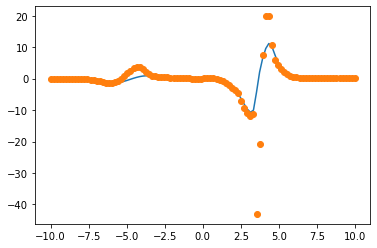

In [33]:
plt.plot(x, dt.reshape(x_grid.shape)[frame, :])
plt.plot(x, (theta @ coeffs_mse).reshape(x_grid.shape)[frame, :], 'o')

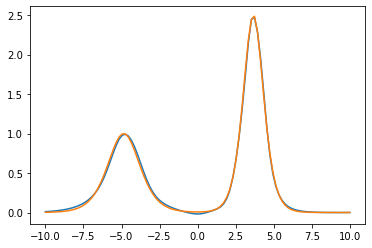

In [32]:
plt.plot(x, prediction.reshape(x_grid.shape)[frame, :])
plt.plot(x, u[frame, :])

In [65]:
coeffs_mse

DeviceArray([[ 0.0587309 ],
             [-0.4365751 ],
             [ 0.05961604],
             [-1.115194  ],
             [-0.724271  ],
             [-6.4445553 ],
             [-3.335464  ],
             [ 1.0035291 ],
             [ 2.4530246 ],
             [ 0.6059731 ],
             [ 2.3979287 ],
             [-0.31474477]], dtype=float32)

In [67]:
# Iterative method
beta = coeffs_mse

for _ in jnp.arange(1e4):
    w = jnp.diag((1 / ((dt - theta @ beta)**2 + 1e-8)).squeeze())
    X_prime = w @ theta
    y_prime = w @ dt
    beta = jnp.linalg.lstsq(X_prime, y_prime)[0]

In [68]:
beta

DeviceArray([[ 0.05831518],
             [-0.8046696 ],
             [ 0.74528563],
             [-0.53477263],
             [-0.4203826 ],
             [-0.23274411],
             [ 0.17999166],
             [-0.5268834 ],
             [ 0.02996622],
             [ 0.14263909],
             [-0.5036721 ],
             [ 0.9691549 ]], dtype=float32)

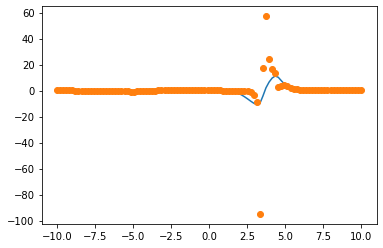

In [69]:
plt.plot(x, dt.reshape(x_grid.shape)[frame, :])
plt.plot(x, (theta @ beta).reshape(x_grid.shape)[frame, :], 'o')

In [70]:
# So the mse method seems to be best....

In [71]:
# Now let's try and get the coeffs based on the mse distance
w = jnp.diag((1 / ((prediction - y)**2 + 1e-8)).squeeze())
X_prime = w @ theta
y_prime = w @ dt

coeffs_mse = jnp.linalg.lstsq(X_prime, y_prime)[0]
print(coeffs_mse)

[[ 0.0587309 ]
 [-0.4365751 ]
 [ 0.05961604]
 [-1.115194  ]
 [-0.724271  ]
 [-6.4445553 ]
 [-3.335464  ]
 [ 1.0035291 ]
 [ 2.4530246 ]
 [ 0.6059731 ]
 [ 2.3979287 ]
 [-0.31474477]]


In [77]:
jnp.sum(jnp.log((dt - theta @ coeffs_mse)**2))

DeviceArray(-3706.0835, dtype=float32)

In [46]:
def loss_fn_weighted_reg(params, state, model, x, y):
    """ first argument should always be params!
    """
    variables = {"params": params, **state}
    (prediction, dt, theta, coeffs, z), updated_state = model.apply(
        variables, x, mutable=list(state.keys())
    )
    

    tau_ml = 1 / jnp.mean((prediction - y) ** 2)
    p_mse, MSE = normal_LL(prediction, y, tau_ml)

    w = jnp.diag((1 / ((prediction - y)**2 + 1e-6)).squeeze())
    X_prime = w @ theta
    y_prime = w @ dt
    coeffs_mse = ridge(X_prime, y_prime, 1e-4)
    p_reg = -jnp.sum(jnp.log(1e-6 + (dt - theta @ coeffs_mse)**2))
    reg = jnp.mean((dt - theta @ coeffs_mse)**2)
    
    loss = MSE + reg

    metrics = {
        "loss": loss,
        "p_mse": p_mse,
        "mse": MSE,
        "p_reg": p_reg,
        "reg": reg,
        "coeff": coeffs_mse,
        "tau": tau_ml,
        "w_mean": jnp.mean(w)
    }
    return loss, (updated_state, metrics, (prediction, dt, theta, coeffs))

In [47]:
dd

NameError: name 'dd' is not defined

In [48]:
model = DeepmodBayes([30, 30, 30, 1])
variables = model.init(key, X)

optimizer = optim.Adam(learning_rate=2e-3, beta1=0.99, beta2=0.99)
state, params = variables.pop("params")
optimizer = optimizer.create(params)

In [49]:
# only train mse, stop at minimum mse testset
optimizer, state = train_probabilistic_simple(
    model,
    optimizer,
    state,
    loss_fn_weighted_reg,
    X,
    y,
    max_epochs=5000)

MSE step 0: 0.46275028586387634
MSE step 1000: 7.847891330718994
MSE step 2000: 2.307772159576416
MSE step 3000: 2.3550801277160645
MSE step 4000: 3.930241823196411


KeyboardInterrupt: 

In [34]:
variables = {"params": optimizer.target, **state}
prediction, dt, theta, coeffs, _ = model.apply(variables, X, mutable=list(state.keys()))[0]

In [35]:
coeffs

DeviceArray([[-2.5637485e-03],
             [-3.1718228e+00],
             [ 3.6795761e-02],
             [-2.4440510e-03],
             [ 5.2520383e-02],
             [-1.7292615e+00],
             [-1.8630394e-01],
             [ 3.6669886e-03],
             [ 8.4964726e-03],
             [ 4.0189064e-01],
             [ 7.1437337e-02],
             [-1.0640449e-03]], dtype=float32)

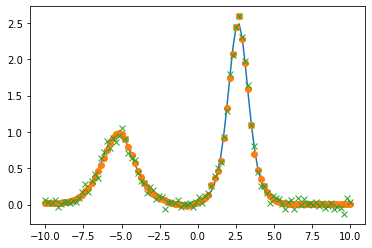

In [36]:
frame = 3
plt.plot(x, u[frame, :])
plt.plot(x, prediction.reshape(x_grid.shape)[frame, :], 'o')
plt.plot(x, y.reshape(x_grid.shape)[frame, :], 'x')